# **Importing the libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# **Importing the dataset**

In [2]:
dataset = pd.read_csv('Life_Expectancy_Data.csv')

In [3]:
dataset.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


# **Defining Features and Target**

In [4]:
dataset.columns = dataset.columns.str.strip()
dataset = dataset.dropna(subset=["Life expectancy"])

In [5]:
X = dataset.drop(columns=["Life expectancy"])
y = dataset["Life expectancy"]

# **Encoding the categorical variables**

In [6]:
numerical_cols = X.select_dtypes(include=['float64', 'int64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

# **Preprocessing the pipeline**

In [7]:
numerical_transformer = SimpleImputer(strategy='mean')
categorical_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [8]:
preprocessor = ColumnTransformer(transformers=[('num', numerical_transformer, numerical_cols), ('cat', categorical_transformer, categorical_cols)])

# **Building the pipeline**

In [9]:
pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=10, min_samples_leaf=5))])

# **Splitting the dataset into training and test set**

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# **Training the model on the pipeline**

In [11]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', SimpleImputer(),
                                                  Index(['Year', 'Adult Mortality', 'infant deaths', 'Alcohol',
       'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI',
       'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Country', 'Status'], dtype='object'))])),
                ('regressor',
                 DecisionTreeRegressor(max_depth=10, min_samples_leaf=5,
                                       min_samples_split=10,
                                       random_state=42))])

# **Predicting the test set results**

In [12]:
y_pred = pipeline.predict(X_test)
comparison = np.concatenate((y_pred.reshape(-1, 1), y_test.to_numpy().reshape(-1, 1)), axis=1)
comparison_dataset = pd.DataFrame(comparison, columns=['Predicted', 'Actual'])
comparison_dataset = comparison_dataset.round(2)
print(comparison_dataset.head(20))

    Predicted  Actual
0       57.66    56.5
1       69.56    73.0
2       82.43    82.5
3       75.54    75.6
4       51.50    53.0
5       69.56    65.2
6       73.78    72.4
7       73.78    74.1
8       77.97    77.0
9       67.72    67.8
10      74.15    73.1
11      73.63    75.1
12      45.36    44.3
13      46.64    47.9
14      75.93    74.3
15      75.79    74.6
16      78.17    78.4
17      76.54    77.7
18      78.64    79.1
19      72.77    73.3


# **Evaluating the model**

In [13]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [14]:
print(f"Mean Absolute Error (MAE): {mae:,.2f} years")
print(f"Mean Squared Error (MSE): {mse:,.2f} years²")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f} years")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 1.52 years
Mean Squared Error (MSE): 5.71 years²
Root Mean Squared Error (RMSE): 2.39 years
R² Score: 0.9340


# **Visualizing the results**

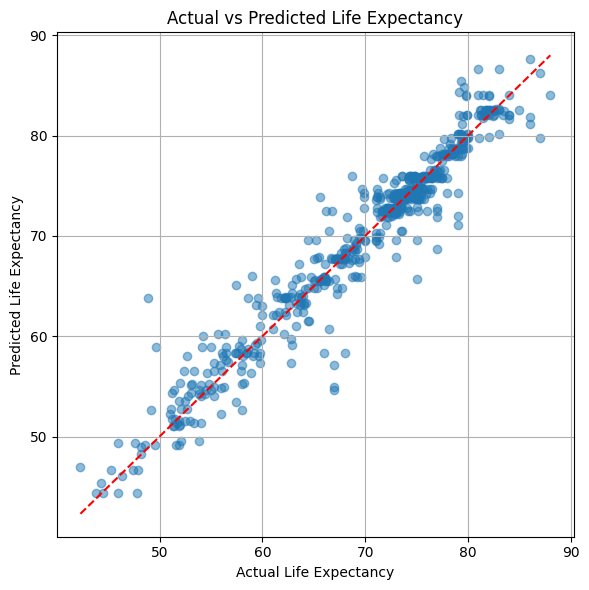

In [15]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Actual vs Predicted Life Expectancy')
plt.grid(True)
plt.tight_layout()
plt.show()

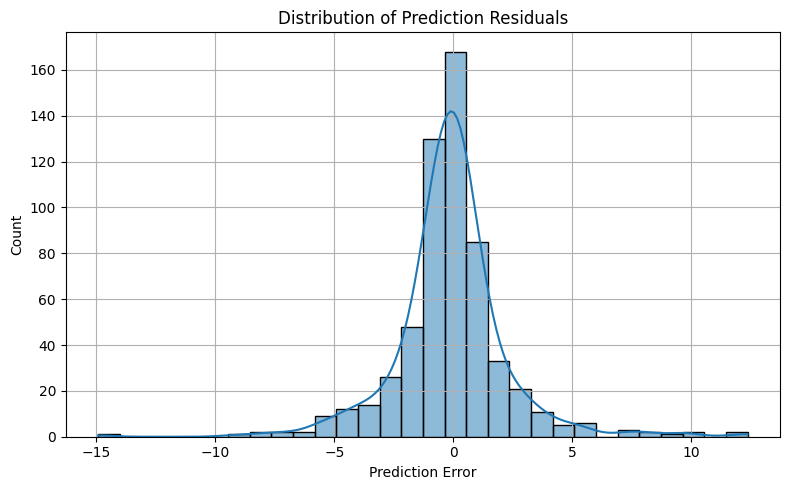

In [16]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.title('Distribution of Prediction Residuals')
plt.xlabel('Prediction Error')
plt.grid(True)
plt.tight_layout()
plt.show()